In [20]:
from matplotlib import pyplot as plt
# from brokenaxes import brokenaxes
import numpy as np
import os
import sys
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

my_figsize = [20, 12]
my_fontsize = 75
WIDTH = 0.05  # the width of the bars
SHORT = 100001 # 100KB
LONG = 1000000 # 1000KB
METRICS = ['FCT', 'GOODPUT']


os.chdir(sys.path[0])
os.chdir('./')

SCHEMES = [
    "../../Ideal/DATA/NSDI25/Multipods/Incast",
    "zeropod-multipods",
    "../../ESN/DATA/NSDI25/singlepod/incast", 
    ]
workloads = ["incast_20", "incast_40", "incast_60", "incast_80", "incast_100", "incast_120"]
incast_degree = [30, 55, 80, 105, 130, 155, 180, 205, 230, 255]

DATA_DIR_TEMP = '{scheme}/DATA_zeropod_{load}/'

data = {}
for scheme in SCHEMES:
    data[scheme] = {}
    for workload in workloads:
        data[scheme][workload] = {}
    
for scheme in SCHEMES:
    for workload in workloads:
        dir_path = DATA_DIR_TEMP.format(scheme=scheme, workload=workload)
        data[scheme][workload]['PATH'] = dir_path
        for metric in METRICS:
            data_path = dir_path + metric + '.txt'
            data[scheme][workload][metric] = np.loadtxt(data_path)

20
40
60
80
100
120
20
40
60
80
100
120
20
40
60
80
100
120
{'Ideal': [0.1660000000001105, 0.324000000000213, 0.48600000000043053, 0.6460000000005905, 0.8060000000007506, 0.9660000000009106], 'dctcp-osub': [0.18795999999676738, 1.2927551999393216, 1.3529967999128534, 1.6168799997662298, 1.7075439996996344, 1.8616511996116802], 'zeropod-multipods': [0.5406021481100254, 0.975752456319201, 1.0548044366769371, 1.2733536969165016, 1.4897035280558857, 1.5550166180502423]}


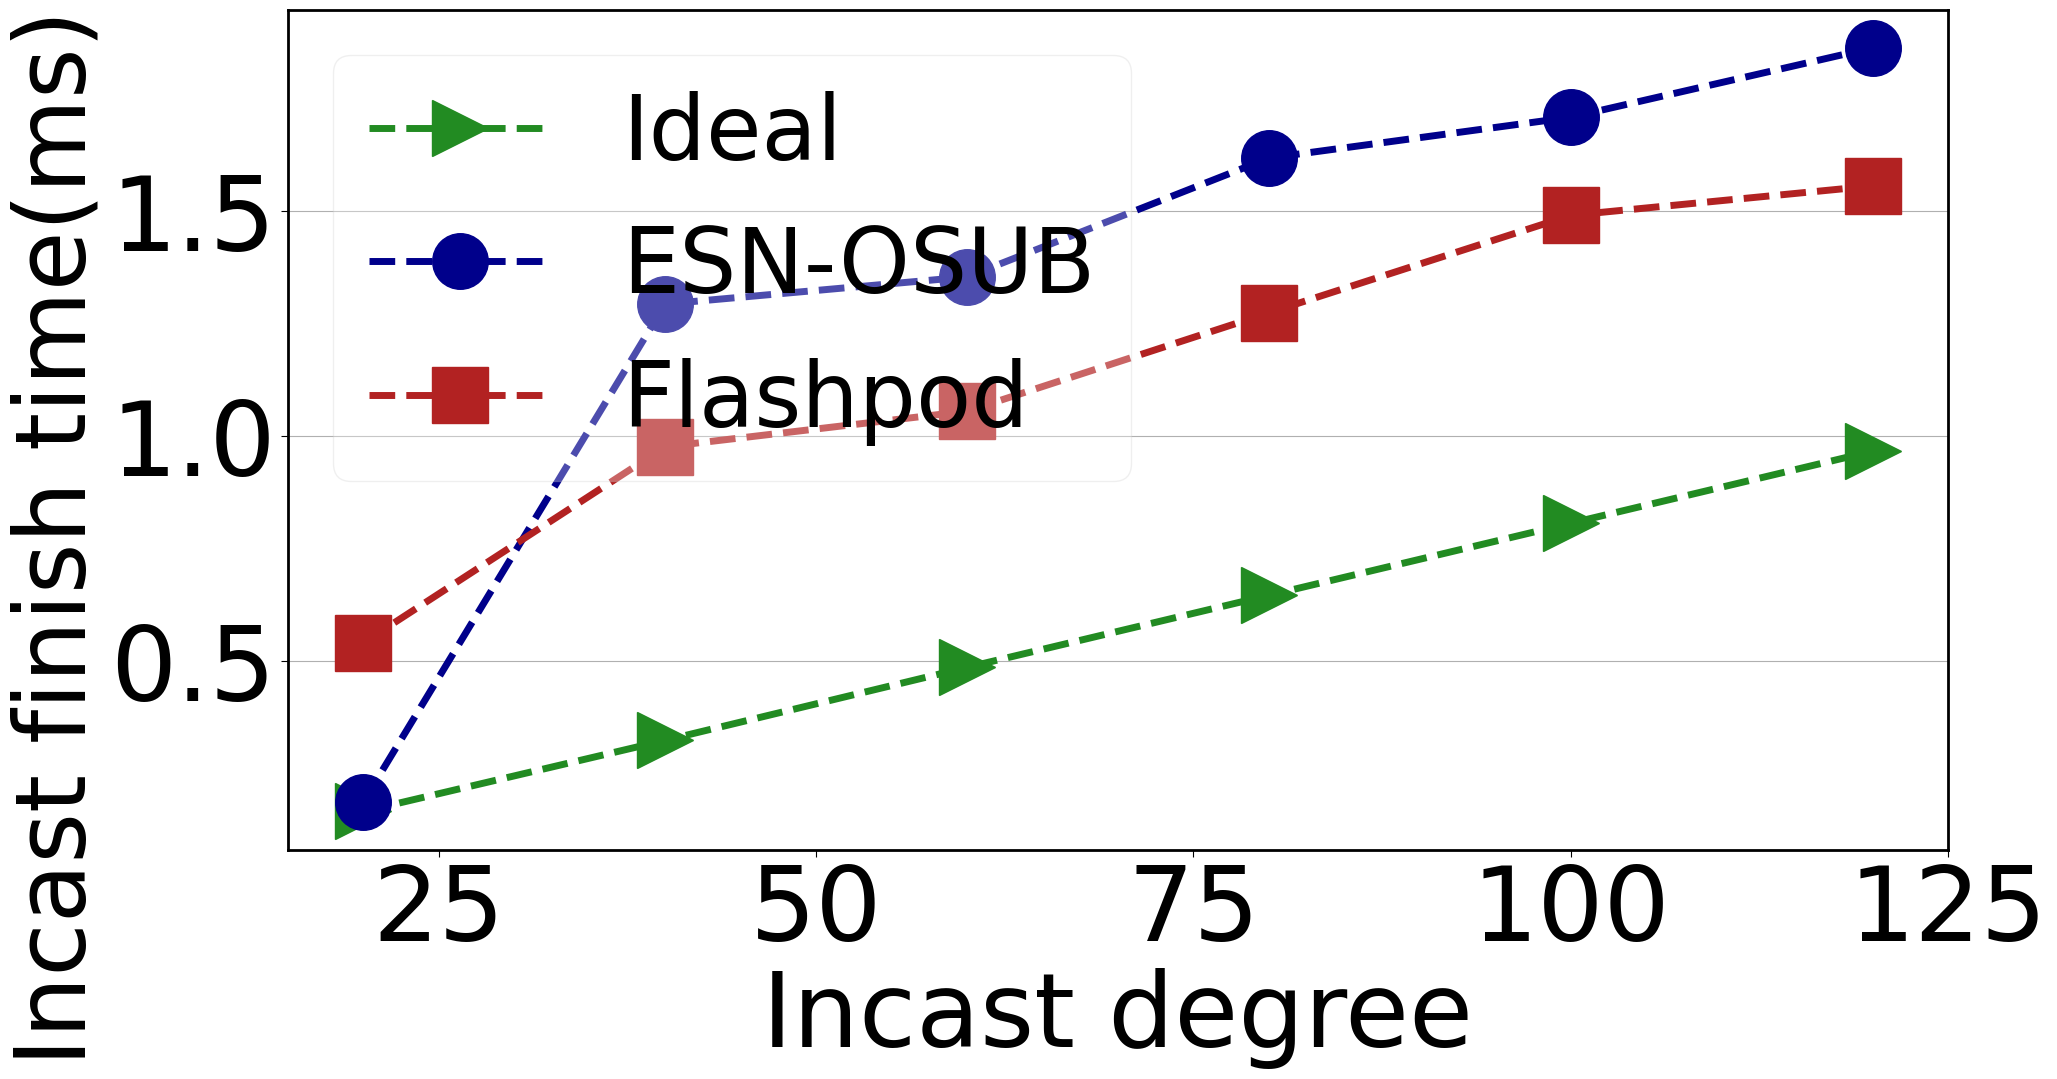

In [35]:
WIDTH = 0.05
def incast_finish_time():
    results = {}
    for i, scheme in enumerate(SCHEMES):
        results[scheme] = []
        for workload in workloads:
            incast_fct = data[scheme][workload]['FCT'][:, 7] # fct
            print(len(incast_fct))
            incast_finish_time = max(incast_fct)
            results[scheme].append(incast_finish_time*1e3)
    



    fig, ax = plt.subplots(figsize=my_figsize)
    # plt.subplots_adjust(left=0.10, right=0.96, bottom=0.15, top=0.9)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    

    for i, scheme in enumerate(SCHEMES):
        ax.plot(incast_degree, results[SCHEMES[i]], color =colors[i], marker =markers[i], markersize=40, linestyle = '--', linewidth=5, label = labels[i])
    print(results)
    # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
    # ax.set_ylabel('Goodput\n(normalized)', fontsize=my_fontsize)
    ax.set_ylabel('Incast finish time(ms)       ', fontsize=my_fontsize-5)
    # ax.set_xticks(x_tick)
    # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
    ax.set_xlabel("Incast degree", fontsize=my_fontsize)
    # ax.set_xticklabels(labels, fontsize=my_fontsize)
    ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-10, framealpha=0.3)
    ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
    # ax.set_xticks()
    # ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-5, handlelength = 1.5, borderpad = 0.2,  labelspacing = 0.3, columnspacing = 1.0)

    

    # plt.xticks(fontsize=my_fontsize-5)
    ax.tick_params(axis='both', which='both', length=5)
    # plt.ylim((0, 250))
    # plt.yticks(np.arange(-1,1.01,0.2), [1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # plt.yticks(np.arange(0,1.01,0.2))
    ax.grid(axis="y")
    
    # plt.yticks(fontsize=my_fontsize-5)
    plt.subplots_adjust(left=0.16, right=0.99, bottom=0.2, top=0.9)
    plt.savefig('../FIGS/microbenchmarks/incast_finish_time_multipods.pdf', bbox_inches='tight')
colors = ['forestgreen', 'darkblue', 'firebrick']  
markers = ['>', 'o', 's', 'd']          
labels = ['Ideal', 'ESN-OSUB', 'Flashpod']
incast_finish_time()

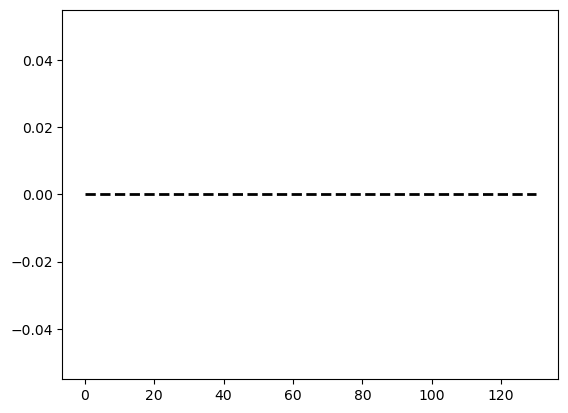

In [22]:
plt.plot([0, 130], [0, 0], color='black', linewidth=2, linestyle='--')